In [1]:
# --- 1. AREA SETUP (minx, miny, maxx, maxy) & DATA RETRIEVAL ---
import warnings
# Suppress all FutureWarnings (they're super annyoing and clutter the output)
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import pygeohydro as gh
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Create a bounding box for our data
bbox = [-77.5, 36.5, -75.0, 40.0]

# Convert the bounding box into a GeoDataFrame, defining the CRS as 4326 (standard Latitude/Longitude)
geometry = gpd.GeoDataFrame({'geometry': [box(*bbox)]}, crs="EPSG:4326")

# Fetch NLCD data using nlcd_bygeom, providing the resolution (in meters) and the years in a dictionary
# The result is a dictionary, so we access it with the key 0
print("Fetching NLCD data from USGS...")
nlcd_dict = gh.nlcd_bygeom(geometry, resolution=30, years={'cover': [2001, 2021]})
nlcd = nlcd_dict[0] # The 0 index corresponds to our geometry
print("...Fetching complete!")

Fetching NLCD data from USGS...
...Fetching complete!


In [2]:
# --- 2. SEPARATE YEARS, CLASSES, AND MAKE A FILTER ---

# The returned object will have 'cover_2001' and 'cover_2021' variables
ds2001 = nlcd['cover_2001']
ds2021 = nlcd['cover_2021']

# Define classes (41, 42, and 43 are forest classes, 90 and 95 are wetland classes)
was_forest = ds2001.isin([41, 42, 43])
is_wetland = ds2021.isin([90, 95])

# Our filter asks: which pixels WERE a forest in 2001 and are NOW a wetland in 2021?
ghost_forest_mask = was_forest & is_wetland

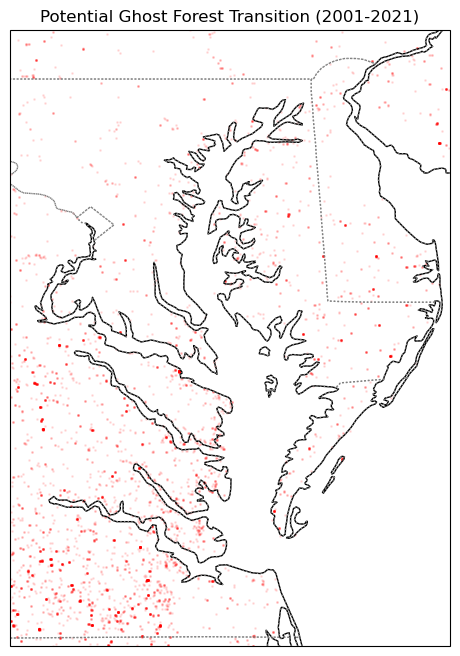

Number of 30m pixels identified as ghost forest transition: 4915.0


In [3]:
# --- 3. APPLY FILTER AND PLOT ---

# Create the transition map (1.0 for ghost forest, NaN otherwise)
transition_map = ghost_forest_mask.where(ghost_forest_mask == True, np.nan).astype(float)

# FIX: Extract lons and lats from the map before plotting
# We stack the dimensions and drop NaNs to get only the coordinates of the "True" pixels
valid_coords = transition_map.stack(pixel=('x', 'y')).dropna('pixel')
lons = valid_coords.x.values
lats = valid_coords.y.values

# Setup with a Cartopy projection
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree()) 

# Adding coastline and geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.STATES, linestyle=':', edgecolor='gray')

# Plotting using the extracted lons/lats
ax.scatter(lons, 
           lats, 
           s=1, 
           color='red', 
           alpha=0.1, 
           transform=ccrs.PlateCarree()
          )

# Use the bbox defined earlier in the code
ax.set_extent([-77.5, -75.0, 36.5, 40.0], crs=ccrs.PlateCarree())

plt.title('Potential Ghost Forest Transition (2001-2021)')
plt.show()

# Statistical count
count = np.nansum(transition_map.values)
print(f"Number of 30m pixels identified as ghost forest transition: {count}")

In [4]:
# --- 1. LOAD DATA ---
dfrslr = r"../TidalGaugeTest/RSLR_Trend_Summary.csv"
dfsalinity = r"../TidalSalinityTest/Salinity_Trend_Summary.csv"
rslr_df = pd.read_csv(dfrslr)
salinity_df = pd.read_csv(dfsalinity)

# --- 2. CONVERT TO GEOPANDAS ---
def to_gdf(df, lon_col='Lon', lat_col='Lat'):
    geometry = [Point(xy) for xy in zip(df[lon_col], df[lat_col])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    # Project to UTM 18N (meters) for accurate 25km distance calculation
    return gdf.to_crs("EPSG:26918")

rslr_gdf = to_gdf(rslr_df)
salinity_gdf = to_gdf(salinity_df)

# --- 3. CONVERT NLCD PIXELS TO POINTS ---
# Assuming 'valid_pixels' from your previous code:
pixel_gdf = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in zip(lons, lats)], # lons/lats from NLCD script
    crs="EPSG:4326"
).to_crs("EPSG:26918")

# --- 4. CREATE 15KM BUFFERS ---
# Buffer is in meters, so 15000 = 15km
rslr_gdf['geometry_buffer'] = rslr_gdf.geometry.buffer(15000)

# --- 5. SPATIAL COUNTS ---
results = []

for idx, station in rslr_gdf.iterrows():
    circle = station['geometry_buffer']
    
    # Count Salinity stations inside this circle
    sal_inside = salinity_gdf[salinity_gdf.geometry.within(circle)]
    avg_sal_rate = sal_inside['Rate (PPT/yr)'].mean() if not sal_inside.empty else 0
    
    # Count Ghost Forest pixels inside this circle
    pixel_count = pixel_gdf[pixel_gdf.geometry.within(circle)].shape[0]
    
    results.append({
        'Station': station['Station ID'],
        'RSLR Rate (mm/yr)': station['Rate (mm/yr)'],
        'Avg Salinity Rate (PPT/yr)': avg_sal_rate,
        'Ghost Forest Pixels': pixel_count,
        'Salinity Station Count': len(sal_inside)
    })

# --- 6. FINAL DATASET ---
comparison_df = pd.DataFrame(results)
comparison_df

,Station,RSLR Rate (mm/yr),Avg Salinity Rate (PPT/yr),Ghost Forest Pixels,Salinity Station Count
0,8635750,7.579530,0.026686,121,1
1,8639348,6.186681,0.025869,44,12
2,8638610,6.746291,0.021419,32,14
3,8638901,6.773640,0.009827,1,5
4,8632200,5.544813,0.023755,29,4
5,8637689,6.438762,0.003542,142,4
6,8571421,7.580189,0.037403,1,3
7,8636580,6.448224,0.024494,97,5
8,8577330,6.602620,0.018855,43,6
9,8635027,10.020287,0.035703,59,1


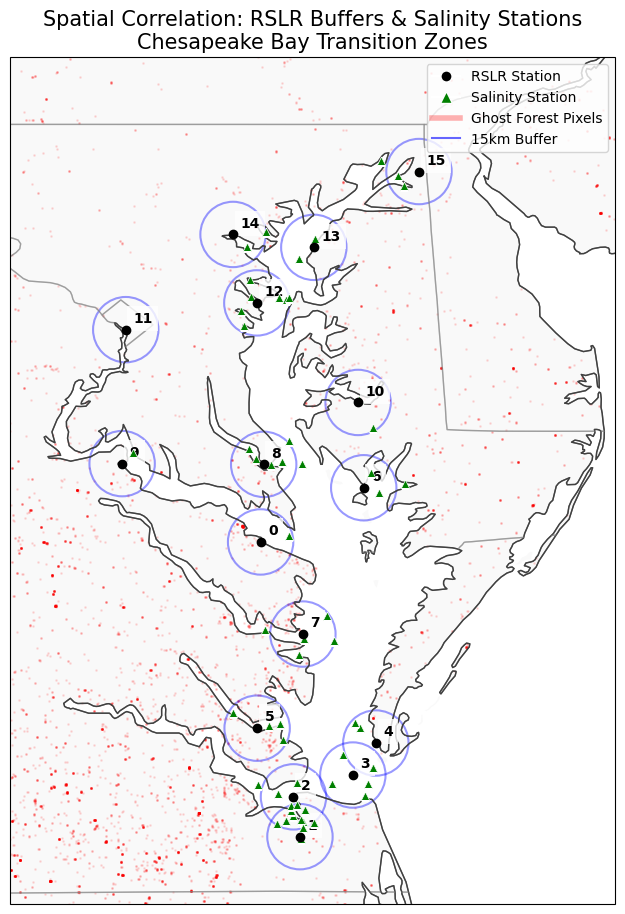

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Circle

# Setup the map projection
fig = plt.figure(figsize=(11, 11))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add geographic context
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.STATES, edgecolor='gray', alpha=0.5)
ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')
ax.set_extent([-77.5, -75.0, 36.5, 40.0], crs=ccrs.PlateCarree())

# Plot the NLCD transition pixels as a background density
ax.scatter(lons, lats, s=1, color='red', alpha=0.1, transform=ccrs.PlateCarree(), label='Ghost Forest Pixels')

# Loop through RSLR stations to draw buffers, labels, and salinity stations
for idx, row in comparison_df.iterrows():
    # Get original lat/lon from the RSLR dataframe
    lon, lat = rslr_df.iloc[idx]['Lon'], rslr_df.iloc[idx]['Lat']
    
    # Draw the 15km buffer circle (0.1351)
    circle_patch = plt.Circle((lon, lat), 0.1351, color='blue', fill=False, 
                              linewidth=1.5, alpha=0.4, transform=ccrs.PlateCarree())
    ax.add_patch(circle_patch)
    
    # Plot Salinity Stations as Green Triangles
    # We use the 'geometry_buffer' from our rslr_gdf analysis to find the stations
    circle_geom = rslr_gdf.iloc[idx]['geometry_buffer']
    sal_inside = salinity_gdf[salinity_gdf.geometry.within(circle_geom)]
    
    # Convert projected UTM points back to Lon/Lat for plotting
    sal_inside_latlon = sal_inside.to_crs("EPSG:4326")
    
    ax.scatter(sal_inside_latlon.geometry.x, sal_inside_latlon.geometry.y, 
               marker='^', color='green', s=40, edgecolors='white', linewidth=0.5,
               transform=ccrs.PlateCarree(), zorder=4)
    
    # Plot the RSLR tidal station point (the center)
    ax.plot(lon, lat, 'ko', markersize=6, transform=ccrs.PlateCarree(), zorder=5)
    
    # Add a numbered label for the RSLR station
    ax.text(lon + 0.03, lat + 0.03, str(idx), fontsize=10, weight='bold',
            transform=ccrs.PlateCarree(), bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Create a custom legend to explain the symbols
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='RSLR Station', markerfacecolor='black', markersize=8),
    Line2D([0], [0], marker='^', color='w', label='Salinity Station', markerfacecolor='green', markersize=8),
    Line2D([0], [0], color='red', alpha=0.3, lw=4, label='Ghost Forest Pixels'),
    Line2D([0], [0], color='blue', lw=1.5, alpha=0.6, label='15km Buffer')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.title("Spatial Correlation: RSLR Buffers & Salinity Stations\nChesapeake Bay Transition Zones", fontsize=15)
plt.show()

In [6]:
# Calculate correlation matrix
correlation = comparison_df[['RSLR Rate (mm/yr)', 'Avg Salinity Rate (PPT/yr)', 'Ghost Forest Pixels']].corr()

print("--- Correlation with Ghost Forest Pixels ---")
print(correlation['Ghost Forest Pixels'])

--- Correlation with Ghost Forest Pixels ---
RSLR Rate (mm/yr)             0.233140
Avg Salinity Rate (PPT/yr)    0.119654
Ghost Forest Pixels           1.000000
Name: Ghost Forest Pixels, dtype: float64


In [7]:
import statsmodels.api as sm
import numpy as np

# Create the Binary Target
# Let's define a "Hotspot" as any area with > 20 pixels
threshold = 32
comparison_df['Is Hotspot?'] = (comparison_df['Ghost Forest Pixels'] > threshold).astype(int)

# Define Variables
X = comparison_df[['RSLR Rate (mm/yr)', 'Avg Salinity Rate (PPT/yr)']]
X = sm.add_constant(X) 
y = comparison_df['Is Hotspot?']

# Fit the Logistic Regression Model
# We use sm.Logit instead of sm.OLS
logit_model = sm.Logit(y, X).fit()

print(logit_model.summary())

# Convert coefficients to Odds Ratios for easier interpretation
print("\n--- Odds Ratios ---")
print(np.exp(logit_model.params))

Optimization terminated successfully.
         Current function value: 0.524568
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Is Hotspot?   No. Observations:                   16
Model:                          Logit   Df Residuals:                       13
Method:                           MLE   Df Model:                            2
Date:                Fri, 01 May 2026   Pseudo R-squ.:                  0.2346
Time:                        13:28:33   Log-Likelihood:                -8.3931
converged:                       True   LL-Null:                       -10.965
Covariance Type:            nonrobust   LLR p-value:                   0.07639
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -3.6896      4.406     -0.837      0.402     -

In [8]:
import pandas as pd
import numpy as np

# Define your increments (Step Sizes)
# We want to see the effect of 1mm for RSLR and 0.01 PPT for Salinity
increments = pd.Series({'RSLR Rate (mm/yr)': 1.0, 'Avg Salinity Rate (PPT/yr)': 0.01})

# Get the raw coefficients from the model
params = logit_model.params.drop('const') # We don't need the intercept for this

# Calculate the Scaled Odds Ratio
# Math: exp(coefficient * increment)
scaled_odds = np.exp(params * increments)

# Format into a nice readable DataFrame
interpretation_df = pd.DataFrame({
    'Change (Increment)': increments,
    '% Increase of "Hotspot" Risk': (scaled_odds - 1) * 100
})

print("Practical Interpretation of Odds")
interpretation_df

Practical Interpretation of Odds


,Change (Increment),"% Increase of ""Hotspot"" Risk"
RSLR Rate (mm/yr),1.00,38.474405
Avg Salinity Rate (PPT/yr),0.01,110.937874
